#### Visualizing Ming Chen's regional MPAS meshes
- mesh plot
- save holoviews plot as png file
- Subsetting
  - Bounding box
  - Bounding circle
  - Nearest neighbor

Ming Ge June 2025

In [1]:
import uxarray as ux
import cartopy.crs as ccrs 

In [2]:
#dir_data = "/glade/derecho/scratch/duda/mpas_tutorial/240-48km_variable/"

flnm_grid = '/glade/derecho/scratch/chenming/CONUS.x1.2621442.grid.nc'
flnm_data = flnm_grid 

uxds_mpas = ux.open_dataset(flnm_grid, flnm_data)

uxgrid = uxds_mpas.uxgrid 

:Overlay
   .Path.I      :Path   [Longitude,Latitude]
   .Coastline.I :Feature   [Longitude,Latitude]
   .States.I    :Feature   [Longitude,Latitude]
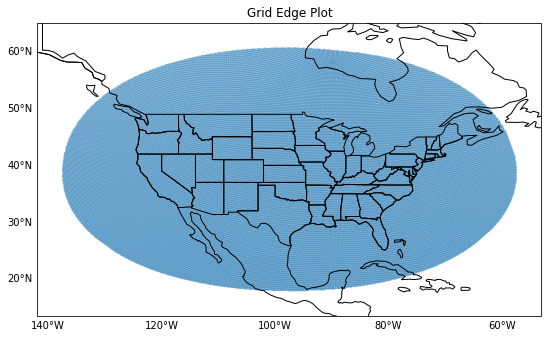

In [4]:
#proj = ccrs.Orthographic(central_latitude=cenlat, central_longitude=cenlon)
proj = ccrs.PlateCarree()
plot_mesh = uxgrid.plot.edges(backend='matplotlib', 
    projection=proj, features=["states", "coastline"],
                  height=500, width=750,
                  linewidth = .2,
                  color="black", 
                  periodic_elements="split",
                  title="Grid Edge Plot")

plot_mesh 

#### Save plot

In [5]:
import holoviews as hv
hv.save(plot_mesh , 'regional_mesh_mingChen', fmt='png') 

#### Subsetting
- Bounding box

:Overlay
   .Path.I      :Path   [Longitude,Latitude]
   .Coastline.I :Feature   [Longitude,Latitude]
   .States.I    :Feature   [Longitude,Latitude]
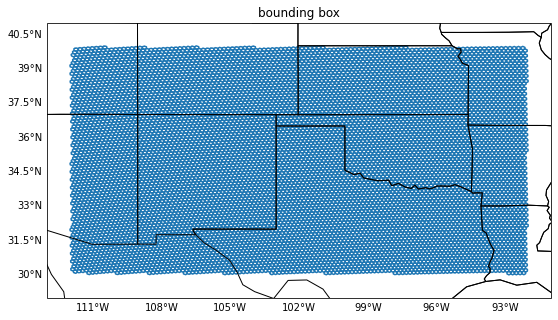

In [16]:
import geoviews.feature as gf
cenlat  = 35
cenlon  = -102
#proj = ccrs.Orthographic(central_latitude=cenlat, central_longitude=cenlon)
 
lon_bounds = (cenlon - 10, cenlon + 10)
lat_bounds = (cenlat - 5, cenlat + 5)

bbox_subset = uxgrid.subset.bounding_box(lon_bounds = lon_bounds, lat_bounds=lat_bounds)
bbox_subset.plot.edges(backend='matplotlib', 
                       height=500, width=750,
                       title="bounding box",
                       projection=proj , 
                       features=["states", "coastline"])  

- Bounding Circle
Using a center coordinate (lon, lat) and a radius (in degrees). The resulting subset will contain all elements within the radius of that circle.

:Overlay
   .Path.I      :Path   [Longitude,Latitude]
   .Coastline.I :Feature   [Longitude,Latitude]
   .States.I    :Feature   [Longitude,Latitude]
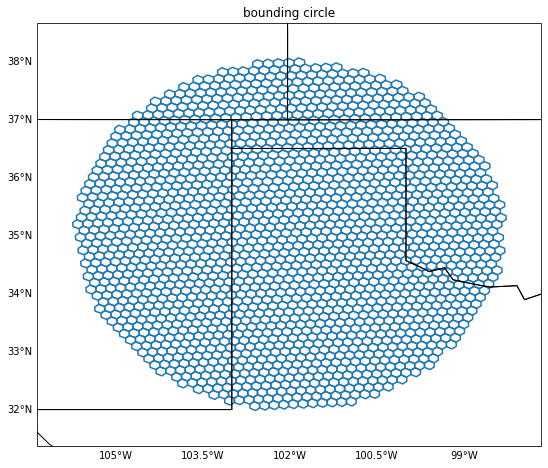

In [20]:
center_coord = [cenlon, cenlat ]
r = 3

bcircle_subset = uxgrid.subset.bounding_circle(center_coord, r)
bcircle_subset.plot.edges(backend='matplotlib', 
                                  height=500, width=750,
                       title="bounding circle",
                       projection=proj , 
                       features=["states", "coastline"])


#### Nearest Neighbor
perform a nearest neighbor subset at some center coordinate (lon, lat) and query for some number of elements k

:Overlay
   .Path.I      :Path   [Longitude,Latitude]
   .Coastline.I :Feature   [Longitude,Latitude]
   .States.I    :Feature   [Longitude,Latitude]
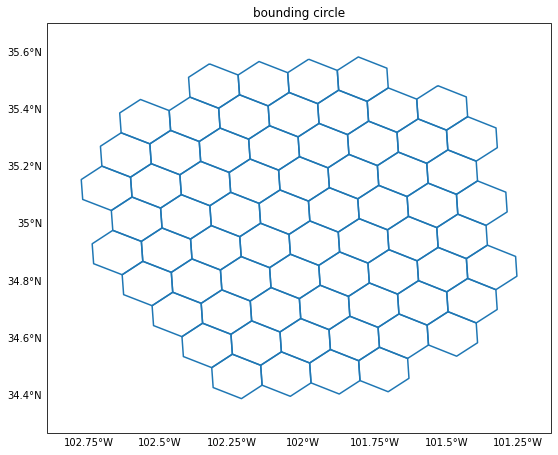

In [22]:
nn_subset = uxgrid.subset.nearest_neighbor(center_coord, k=100, element="nodes")

nn_subset.plot.edges(backend='matplotlib', 
                     height=500, width=750,
                       title="bounding circle",
                       projection=proj , 
                       features=["states", "coastline"])